# Chapter 9 — K-means Clustering

**Goals**

- Implement K-means from scratch (Lloyd's algorithm) with k-means++ init.
- Verify the result matches `sklearn.cluster.KMeans`.
- Visualize clusters on `make_blobs` (well-suited) and `make_moons` (failure mode).
- Pick $K$ with the elbow method and silhouette score.

Pair with `docs/05_clustering.md`.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. K-means from scratch (Lloyd + k-means++)

Three pieces: distance computation, assignment, centroid update — plus careful initialization.

In [2]:
def kmeans_pp_init(X, K, rng):
    """k-means++ initialization: spread centroids by distance."""
    N = X.shape[0]
    idx0 = rng.integers(N)
    centroids = [X[idx0]]
    for _ in range(K - 1):
        diff = X[:, None, :] - np.array(centroids)[None, :, :]
        d2 = np.min(np.sum(diff ** 2, axis=2), axis=1)
        probs = d2 / d2.sum()
        next_idx = rng.choice(N, p=probs)
        centroids.append(X[next_idx])
    return np.array(centroids)

def kmeans(X, K, n_init=10, max_iter=300, tol=1e-6, seed=SEED):
    rng = np.random.default_rng(seed)
    best = {'loss': np.inf}
    for run in range(n_init):
        centroids = kmeans_pp_init(X, K, rng)
        for _ in range(max_iter):
            d = np.sum((X[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
            z = np.argmin(d, axis=1)
            new_centroids = np.array([X[z == c].mean(axis=0) if np.any(z == c) else centroids[c]
                                       for c in range(K)])
            shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids
            if shift < tol: break
        loss = float(np.sum(d[np.arange(len(X)), z]))
        if loss < best['loss']:
            best = {'loss': loss, 'centroids': centroids, 'z': z}
    return best

## 3. Cluster `make_blobs`

In [3]:
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.7, random_state=SEED)
scratch = kmeans(X, K=4)
sk = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X)

print(f'scratch loss = {scratch["loss"]:.2f}')
print(f'sklearn loss = {sk.inertia_:.2f}')
print('cluster ids may differ between runs but the geometry should match.')

scratch loss = 464.96
sklearn loss = 464.96
cluster ids may differ between runs but the geometry should match.


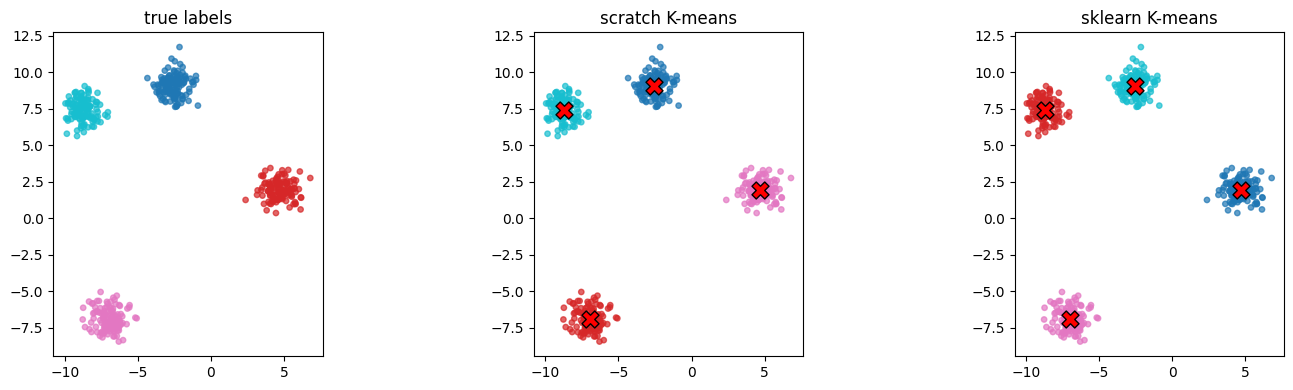

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, labels, centers) in zip(axes, [
    ('true labels', y_true, None),
    ('scratch K-means', scratch['z'], scratch['centroids']),
    ('sklearn K-means', sk.labels_, sk.cluster_centers_),
]):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=15, alpha=0.7)
    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1], marker='X', s=150, c='red', edgecolor='black')
    ax.set_title(title); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## 4. Failure mode — `make_moons`

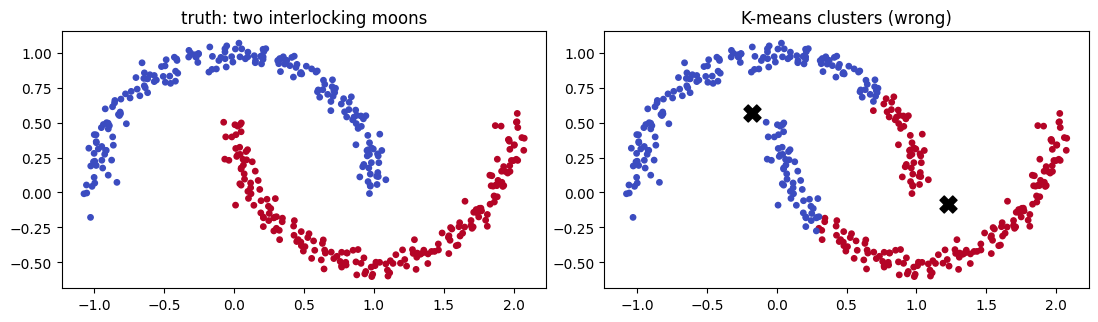

In [5]:
Xm, ym = make_moons(n_samples=400, noise=0.05, random_state=SEED)
scratch_m = kmeans(Xm, K=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap='coolwarm', s=15)
axes[0].set_title('truth: two interlocking moons')
axes[1].scatter(Xm[:, 0], Xm[:, 1], c=scratch_m['z'], cmap='coolwarm', s=15)
axes[1].scatter(scratch_m['centroids'][:, 0], scratch_m['centroids'][:, 1],
                marker='X', s=150, c='black')
axes[1].set_title('K-means clusters (wrong)')
for ax in axes: ax.set_aspect('equal')
plt.tight_layout(); plt.show()

K-means cuts each moon in half along a straight line because it can only produce convex clusters. Non-convex shapes need DBSCAN, spectral clustering, or kernel-based methods.

## 5. Elbow method

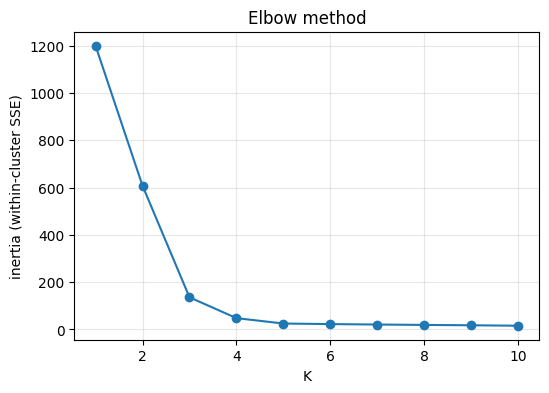

In [6]:
X_blobs, _ = make_blobs(n_samples=600, centers=5, cluster_std=0.8, random_state=SEED)
X_blobs = StandardScaler().fit_transform(X_blobs)
Ks = list(range(1, 11))
inertias = [KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_blobs).inertia_ for k in Ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Ks, inertias, marker='o')
ax.set_xlabel('K'); ax.set_ylabel('inertia (within-cluster SSE)')
ax.set_title('Elbow method'); ax.grid(True, alpha=0.3)
plt.show()

## 6. Silhouette score

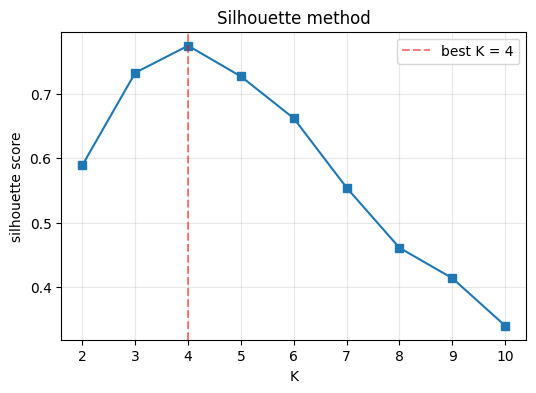

In [7]:
scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_blobs)
    scores.append(silhouette_score(X_blobs, km.labels_))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(2, 11), scores, marker='s')
ax.set_xlabel('K'); ax.set_ylabel('silhouette score')
ax.set_title('Silhouette method')
ax.axvline(int(np.argmax(scores) + 2), color='red', linestyle='--', alpha=0.5,
           label=f'best K = {np.argmax(scores) + 2}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 7. Summary

- K-means alternates *assign* (E-step) and *update* (M-step), monotonically decreasing the loss.
- Initialization matters; k-means++ + multiple restarts is the safe default.
- The elbow and silhouette are *hints* about $K$, not answers.
- K-means fails on non-convex shapes — recognise the failure mode.

**Next:** `projects/project_03_customer_segmentation/` — apply K-means to a real problem.

## Quick Check

1. What objective does K-means actually minimize?
2. Why is K-means not guaranteed to find the global minimum?
3. What does the elbow method tell you, and what is one of its limitations?
4. Why does k-means++ initialization usually beat random init?
5. Name one preprocessing step that significantly changes K-means clusters.


## Further Reading

- Vũ Hữu Tiệp, *Machine Learning cơ bản* — Chương 10 (K-means Clustering).
- Arthur & Vassilvitskii (2007). *k-means++: The Advantages of Careful Seeding.*
- scikit-learn user guide: *Clustering*.
